## Stage 1: Load the RGB Dataset

We start with the EuroSAT RGB dataset — satellite images (64x64 pixels,
3 color channels) already split into train/validation/test sets, each
labeled with one of 10 land cover classes (Forest, Highway, River, etc).

This first block just loads the dataset and inspects one example to
understand its structure before doing anything else with it.

In [1]:
from datasets import load_dataset
rgb_dataset = load_dataset("blanchon/EuroSAT_RGB")

print(rgb_dataset)  # shows train/val/test split sizes

example = rgb_dataset['train'][0]
print(example)                 # raw dict: {'image': ..., 'label': ...}
print(type(example['image']))  # confirm image type (PIL Image)
print(example['image'].size)   # image dimensions (width, height)
print(example['label'])        # numeric class label (e.g. 0)

label_features = rgb_dataset['train'].features['label']
print(label_features.names)  # human-readable class names for each numeric label

README.md:   0%|          | 0.00/3.38k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  105MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 34.8MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

data/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16200 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5400 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5400 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label', 'filename'],
        num_rows: 16200
    })
    test: Dataset({
        features: ['image', 'label', 'filename'],
        num_rows: 5400
    })
    validation: Dataset({
        features: ['image', 'label', 'filename'],
        num_rows: 5400
    })
})
{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=64x64 at 0x7E89A1DEAA50>, 'label': 0, 'filename': 'AnnualCrop_1.tif'}
<class 'PIL.PngImagePlugin.PngImageFile'>
(64, 64)
0
['Annual Crop', 'Forest', 'Herbaceous Vegetation', 'Highway', 'Industrial Buildings', 'Pasture', 'Permanent Crop', 'Residential Buildings', 'River', 'SeaLake']


## Stage 1b: Check Class Balance

Before training anything, we check how many examples exist per class.
An imbalanced dataset (e.g. way more Forest than Highway) could bias
the model, so this is a standard first sanity check.

In [2]:
import pandas as pd
train_label = rgb_dataset['train']['label']
label_names = rgb_dataset['train'].features['label'].names

label_counts = pd.Series(train_label).value_counts().sort_index()
label_counts.index = [label_names[i] for i in label_counts.index]
print(label_counts)

Annual Crop              1791
Forest                   1787
Herbaceous Vegetation    1799
Highway                  1505
Industrial Buildings     1492
Pasture                  1195
Permanent Crop           1481
Residential Buildings    1863
River                    1460
SeaLake                  1827
Name: count, dtype: int64


## Stage 1c: Visualize One Example per Class

A picture is worth a thousand rows of data. This just grabs the first
example of each of the 10 classes and displays them side by side, so
we can visually understand what each class actually looks like.

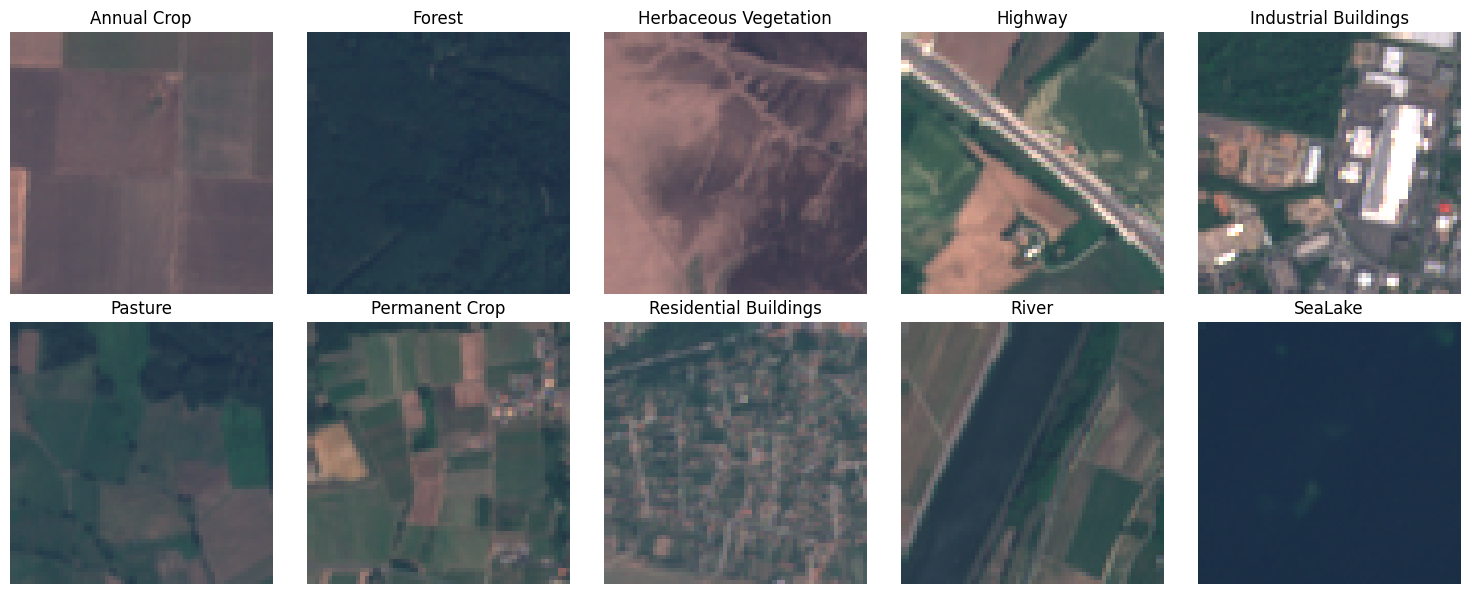

In [3]:
import numpy as np
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 5, figsize = (15,6))
axes = axes.flatten()
for class_idx in range(10):
    for example in rgb_dataset['train']:
      if example['label'] == class_idx:
        axes[class_idx].imshow(example['image'])
        axes[class_idx].set_title(label_names[class_idx])
        axes[class_idx].axis('off')
        break  # stop once we've found one example of this class
plt.tight_layout()
plt.show()

## Stage 1d: Zoom in on Visually Similar Classes

Some classes look alike even to the human eye (e.g. Annual Crop vs
Pasture vs Herbaceous Vegetation — they're all "green fields" of some
kind). Here we line up 5 examples from each of these 4 confusing
classes to see just how similar they really are. This sets expectations
for where our model is likely to struggle.

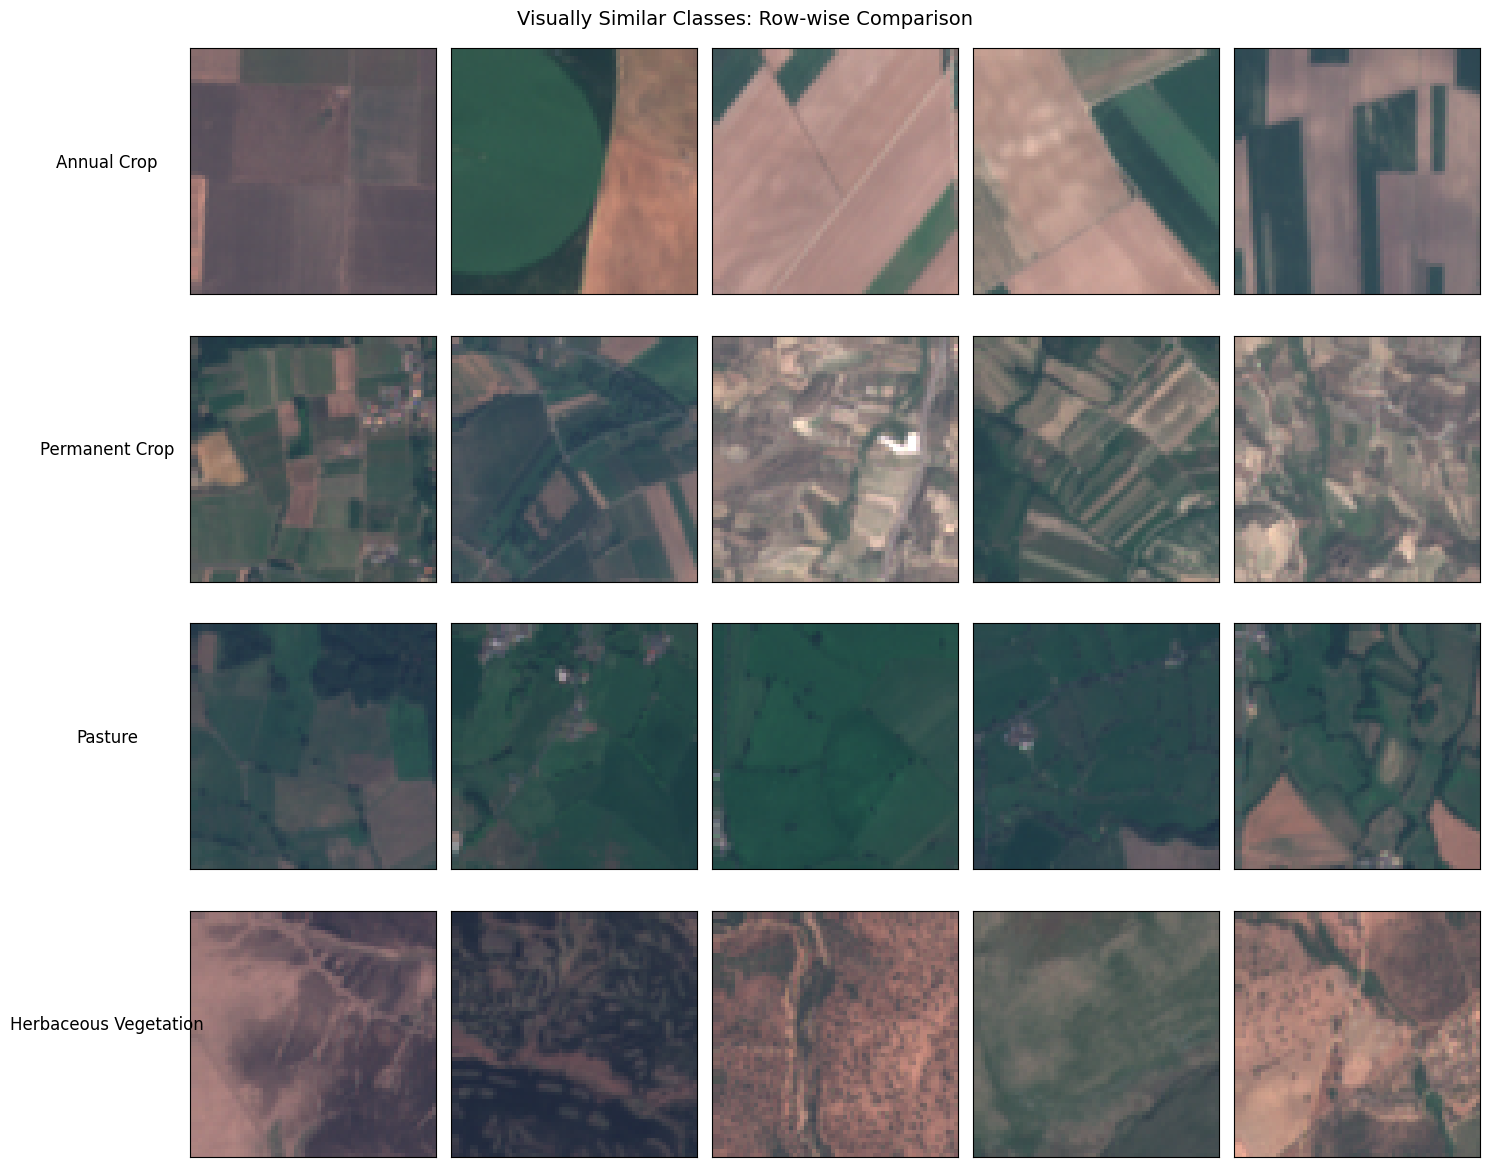

In [4]:
confusing_classes = ['Annual Crop', 'Permanent Crop', 'Pasture', 'Herbaceous Vegetation']
confusing_indices = [label_names.index(c) for c in confusing_classes]

fig, axes = plt.subplots(len(confusing_classes), 5, figsize=(15, 12))

for row, class_idx in enumerate(confusing_indices):
    count = 0
    for example in rgb_dataset['train']:
        if example['label'] == class_idx:
            axes[row, count].imshow(example['image'])
            axes[row, count].set_xticks([])
            axes[row, count].set_yticks([])
            if count == 0:
                axes[row, count].set_ylabel(label_names[class_idx], fontsize=12, rotation=0, labelpad=60)
            count += 1
            if count == 5:
                break  # only need 5 examples per row

plt.suptitle("Visually Similar Classes: Row-wise Comparison", fontsize=14)
plt.tight_layout()
plt.show()

## Stage 2: Turn Images into Numbers (Feature Extraction)

A Random Forest model can't "look" at an image directly — it needs a
fixed list of numbers per example. So we summarize each image's Red,
Green, and Blue channels using 4 simple statistics each (mean, std,
min, max), giving 12 numbers total per image. This is a common,
simple baseline approach before trying anything more advanced.

In [5]:
def extract_rgb_features(image):
    arr = np.array(image)  # shape (64, 64, 3) -> height, width, color channel

    features = []
    for channel in range(3):  # loop over R, G, B channels
        channel_data = arr[:, :, channel]
        features.append(channel_data.mean())  # average brightness
        features.append(channel_data.std())   # how much brightness varies (texture)
        features.append(channel_data.min())   # darkest pixel value
        features.append(channel_data.max())   # brightest pixel value

    return features

# quick test on a single image to confirm the function works as expected
sample_image = rgb_dataset['train'][0]['image']
features = extract_rgb_features(sample_image)
print(features)
print(len(features))  # should be 12 (3 channels x 4 stats)

[np.float64(98.886474609375), np.float64(14.785859240167898), np.uint8(75), np.uint8(195), np.float64(88.305419921875), np.float64(8.35902335238375), np.uint8(76), np.uint8(141), np.float64(95.08349609375), np.float64(5.915325458276027), np.uint8(85), np.uint8(130)]
12


## Stage 2b: Build Full Feature Matrices

Now we apply `extract_rgb_features` to every image in each split
(train/val/test), building X (features) and y (labels) arrays that
scikit-learn models can be trained and evaluated on.

In [6]:
def build_feature_matrix(dataset_split):
    X = []
    y = []

    for example in dataset_split:
        features = extract_rgb_features(example['image'])
        X.append(features)
        y.append(example['label'])

    return np.array(X), np.array(y)

X_train, y_train = build_feature_matrix(rgb_dataset['train'])
print(X_train.shape)  # (num_train_images, 12)
print(y_train.shape)  # (num_train_images,)

X_test, y_test = build_feature_matrix(rgb_dataset['test'])
X_val, y_val = build_feature_matrix(rgb_dataset['validation'])

print(X_test.shape, y_test.shape)
print(X_val.shape, y_val.shape)

(16200, 12)
(16200,)
(5400, 12) (5400,)
(5400, 12) (5400,)


## Stage 3: Train the RGB Baseline Model

We train a Random Forest — a model made of many decision trees that
vote together — on the 12 RGB statistical features. This gives us a
simple baseline accuracy to compare later, more advanced approaches
against.

In [7]:
from sklearn.ensemble import RandomForestClassifier
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42)  # 100 trees, fixed seed for reproducibility
rf_baseline.fit(X_train, y_train)

# Evaluating on the validation set (data the model has never seen during training)
from sklearn.metrics import accuracy_score, classification_report
y_val_pred = rf_baseline.predict(X_val)
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred, target_names=label_names))  # precision/recall/F1 per class

Validation Accuracy: 0.7848148148148149
                       precision    recall  f1-score   support

          Annual Crop       0.81      0.83      0.82       613
               Forest       0.94      0.95      0.94       605
Herbaceous Vegetation       0.81      0.77      0.79       628
              Highway       0.57      0.38      0.46       499
 Industrial Buildings       0.87      0.90      0.88       507
              Pasture       0.77      0.86      0.81       409
       Permanent Crop       0.67      0.66      0.66       481
Residential Buildings       0.68      0.86      0.76       583
                River       0.69      0.67      0.68       511
              SeaLake       0.96      0.91      0.93       564

             accuracy                           0.78      5400
            macro avg       0.78      0.78      0.77      5400
         weighted avg       0.78      0.78      0.78      5400



## Stage 3b: Confusion Matrix

Overall accuracy hides *which* classes get confused with each other.
A confusion matrix shows, for every true class (rows), what the model
actually predicted (columns) — the diagonal is correct predictions,
everything off-diagonal is a mistake worth investigating.

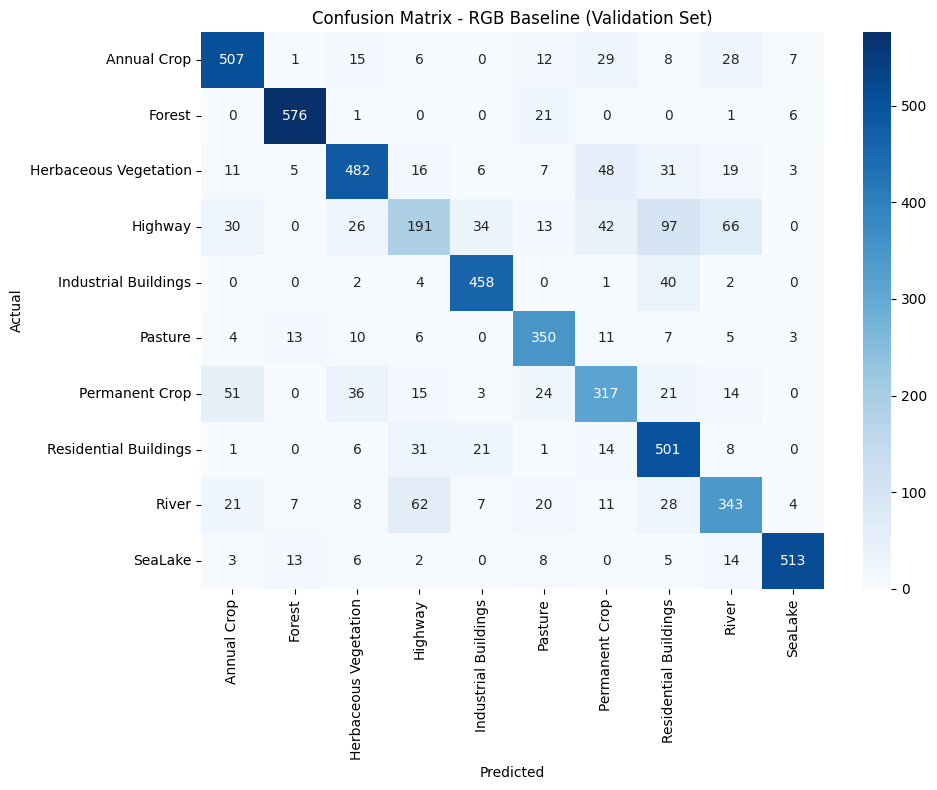

In [8]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=label_names, yticklabels=label_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - RGB Baseline (Validation Set)')
plt.tight_layout()
plt.show()

## Stage 3 Results: RGB Baseline (Random Forest)

- **Model:** Random Forest (100 trees), trained on 12 simple statistical
  features (mean, std, min, max per RGB channel)
- **Validation Accuracy:** 78.5%
- **Strongest classes:** Forest (F1 0.94), SeaLake (F1 0.93) —
  visually distinctive, easy to separate by color alone
- **Weakest class:** Highway (F1 0.46) — commonly confused with
  Residential Buildings and River
- **Key finding:** Highway and River show mutual confusion, likely because
  simple color statistics can't distinguish thin linear road/water
  features from each other or surrounding built-up areas. This motivates
  testing whether multispectral bands (e.g., NIR, SWIR) better separate
  paved surfaces from water.

## Stage 3c: Save the RGB Baseline

I save the trained model and its feature matrices to disk so this
stage's work isn't lost, and so we can reload it later without
retraining, or directly compare it against later models.

In [9]:
import pickle
import os

os.makedirs('models', exist_ok=True)  # create a folder for saved models if it doesn't exist yet

with open('models/rf_baseline_rgb.pkl', 'wb') as f:
    pickle.dump(rf_baseline, f)

print("Model saved successfully")

np.savez('models/rgb_features.npz',
         X_train=X_train, y_train=y_train,
         X_val=X_val, y_val=y_val,
         X_test=X_test, y_test=y_test)

print("Features saved successfully")

# download the saved files to your computer (Colab-specific)
from google.colab import files
files.download('models/rf_baseline_rgb.pkl')
files.download('models/rgb_features.npz')

Model saved successfully
Features saved successfully


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Stage 4: Multispectral Data

The RGB baseline only "sees" what the human eye sees. Satellites like
Sentinel-2 actually capture 13 spectral bands, including wavelengths
invisible to us (Near-Infrared, Short-Wave Infrared). These extra
bands are known to help distinguish surfaces that look similar in
plain color photos (e.g. paved roads vs. bare soil vs. water).

Here we load the multispectral (MSI) version of the same dataset and
inspect one example to understand its shape and value range.

README.md:   0%|          | 0.00/3.46k [00:00<?, ?B/s]

data/train-00000-of-00004.parquet: reconstructing file:   0%|          |  0.00B /  354MB            

data/train-00000-of-00004.parquet: downloading bytes:           |  0.00B            

data/train-00001-of-00004.parquet: reconstructing file:   0%|          |  0.00B /  360MB            

data/train-00001-of-00004.parquet: downloading bytes:           |  0.00B            

...

data/validation-00001-of-00002.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16200 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5400 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5400 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label', 'filename'],
        num_rows: 16200
    })
    test: Dataset({
        features: ['image', 'label', 'filename'],
        num_rows: 5400
    })
    validation: Dataset({
        features: ['image', 'label', 'filename'],
        num_rows: 5400
    })
})
dict_keys(['image', 'label', 'filename'])
<class 'list'>
(64, 64, 13)
int64
9 3490


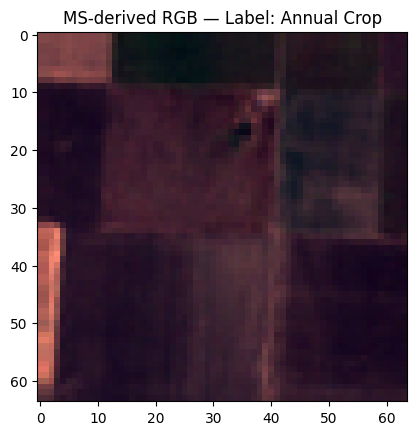

In [10]:
from datasets import load_dataset
ms_dataset = load_dataset("blanchon/EuroSAT_MSI")
print(ms_dataset)

ms_example = ms_dataset['train'][0]
print(ms_example.keys())
print(type(ms_example['image']))

ms_array = np.array(ms_example['image'])
print(ms_array.shape)  # (64, 64, 13) -> 13 spectral bands instead of 3
print(ms_array.dtype)
print(ms_array.min(), ms_array.max())  # raw sensor values, not 0-255 like normal images

# Build a "fake" RGB image from the multispectral bands just to visually
# confirm this is the same scene/class as the RGB version, using the
# bands that correspond to Red, Green, Blue.
rgb_from_ms = ms_array[:, :, [3, 2, 1]]  # Red, Green, Blue order for display
rgb_from_ms_normalized = (rgb_from_ms - rgb_from_ms.min()) / (rgb_from_ms.max() - rgb_from_ms.min())  # scale to 0-1 for display

plt.imshow(rgb_from_ms_normalized)
plt.title(f"MS-derived RGB — Label: {label_names[ms_example['label']]}")
plt.show()

## Stage 4a: Extract Features from All 13 Bands

Same idea as the RGB feature extraction, just generalized to loop over
all 13 spectral bands instead of only 3. This gives us 52 features per
image (13 bands x 4 stats each).

In [11]:
def extract_ms_features(image):
    arr = np.array(image)  # shape (64, 64, 13)

    features = []
    for band in range(arr.shape[2]):  # loop over all 13 bands, not just R/G/B
        band_data = arr[:, :, band]
        features.append(band_data.mean())
        features.append(band_data.std())
        features.append(band_data.min())
        features.append(band_data.max())

    return features

# quick test on one image
sample_ms_features = extract_ms_features(ms_example['image'])
print(sample_ms_features)
print(len(sample_ms_features))  # should be 52 (13 bands x 4 stats)

[np.float64(1323.20263671875), np.float64(31.77755406362271), np.int64(1235), np.int64(1420), np.float64(1124.5146484375), np.float64(69.50756815999988), np.int64(1002), np.int64(1534), np.float64(1044.73193359375), np.float64(98.27143192102214), np.int64(905), np.int64(1664), np.float64(1169.281494140625), np.float64(173.94087876623675), np.int64(893), np.int64(2297), np.float64(1291.627197265625), np.float64(172.792878442333), np.int64(1034), np.int64(2128), np.float64(1553.7548828125), np.float64(302.1431423874835), np.int64(1120), np.int64(2376), np.float64(1765.66943359375), np.float64(368.9827927835962), np.int64(1238), np.int64(2689), np.float64(1748.955322265625), np.float64(396.4747836967891), np.int64(1186), np.int64(2977), np.float64(484.055908203125), np.float64(79.4252366201288), np.int64(353), np.int64(631), np.float64(11.56982421875), np.float64(0.9926524837403834), np.int64(9), np.int64(14), np.float64(2715.398681640625), np.float64(257.53458882569794), np.int64(2248), 

## Stage 4b: Build Multispectral Feature Matrices

Same pattern as before: apply the feature extractor across every
image in train/val/test to get X (features) and y (labels) arrays.

In [12]:
def build_feature_matrix_ms(dataset_split):
    X = []
    y = []

    for example in dataset_split:
        features = extract_ms_features(example['image'])
        X.append(features)
        y.append(example['label'])

    return np.array(X), np.array(y)

X_train_ms, y_train_ms = build_feature_matrix_ms(ms_dataset['train'])
print(X_train_ms.shape)  # (num_train_images, 52)
print(y_train_ms.shape)

X_val_ms, y_val_ms = build_feature_matrix_ms(ms_dataset['validation'])
X_test_ms, y_test_ms = build_feature_matrix_ms(ms_dataset['test'])

print(X_val_ms.shape, y_val_ms.shape)
print(X_test_ms.shape, y_test_ms.shape)

(16200, 52)
(16200,)
(5400, 52) (5400,)
(5400, 52) (5400,)


## Stage 4c: Train and Evaluate the Multispectral Model

Same Random Forest setup as the RGB baseline (100 trees, same random
seed), but now trained on the richer 52-feature multispectral data.
This isolates the effect of "more spectral information" as the only
variable that changed, so the comparison to the RGB baseline is fair.

In [13]:
rf_ms = RandomForestClassifier(n_estimators=100, random_state=42)
rf_ms.fit(X_train_ms, y_train_ms)

y_val_pred_ms = rf_ms.predict(X_val_ms)
print("MS Validation Accuracy:", accuracy_score(y_val_ms, y_val_pred_ms))
print(classification_report(y_val_ms, y_val_pred_ms, target_names=label_names))

MS Validation Accuracy: 0.9
                       precision    recall  f1-score   support

          Annual Crop       0.91      0.90      0.90       613
               Forest       0.98      0.98      0.98       605
Herbaceous Vegetation       0.90      0.93      0.92       628
              Highway       0.76      0.64      0.69       499
 Industrial Buildings       0.89      0.93      0.91       507
              Pasture       0.88      0.91      0.89       409
       Permanent Crop       0.83      0.84      0.84       481
Residential Buildings       0.87      0.92      0.89       583
                River       0.93      0.93      0.93       511
              SeaLake       0.99      0.99      0.99       564

             accuracy                           0.90      5400
            macro avg       0.89      0.90      0.89      5400
         weighted avg       0.90      0.90      0.90      5400



## Stage 4d: Confusion Matrix (Multispectral)

Check whether the extra spectral bands actually fixed the Highway/River
confusion we saw in the RGB baseline, or just shifted the errors
somewhere else.

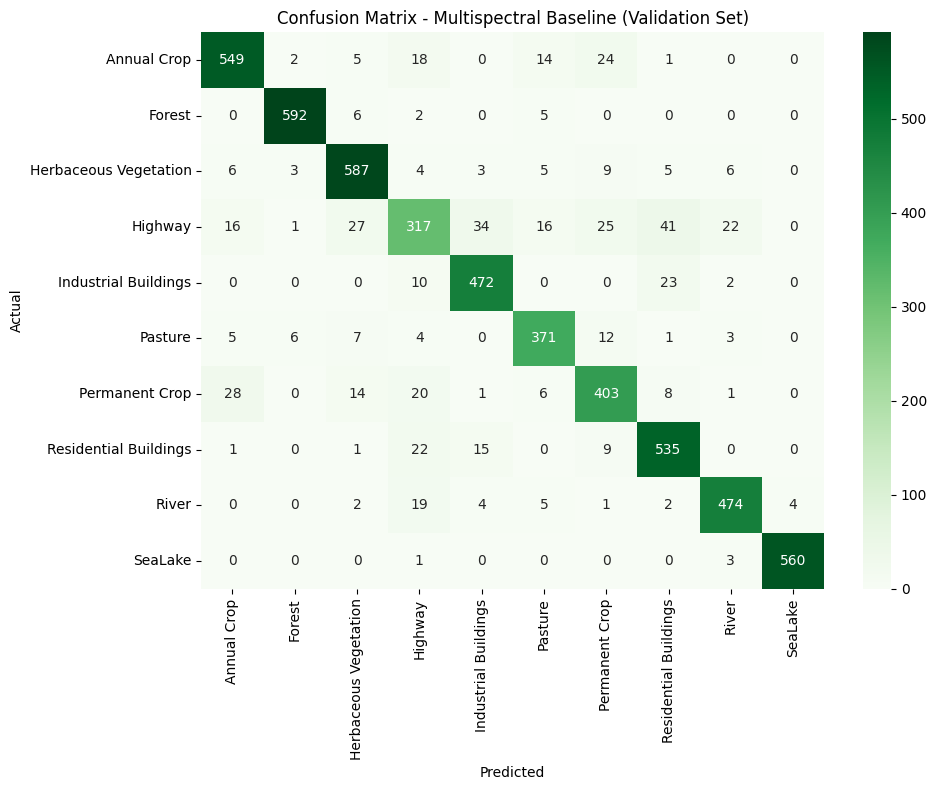

In [14]:
cm_ms = confusion_matrix(y_val_ms, y_val_pred_ms)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_ms, annot=True, fmt='d', xticklabels=label_names, yticklabels=label_names, cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Multispectral Baseline (Validation Set)')
plt.tight_layout()
plt.show()

**Observation:** Highway's confusion shifted away from River and
toward Residential/Industrial Buildings — the SWIR/NIR bands helped
separate roads from water, but roads and buildings still share similar
"paved surface" spectral signatures that are hard to tell apart with
simple per-band statistics.

## Stage 4e: Which Bands Actually Matter? (Feature Importance)

A Random Forest can tell us how much each feature contributed to its
decisions. This helps confirm whether the "extra" bands we added
(beyond plain RGB) are actually being used by the model, or if it's
still mostly relying on visible-light bands.

In [15]:
feature_names = []
for band in range(13):
    feature_names += [f'B{band}_mean', f'B{band}_std', f'B{band}_min', f'B{band}_max']

importances = pd.Series(rf_ms.feature_importances_, index=feature_names).sort_values(ascending=False)
print(importances.head(15))  # top 15 most important features

B1_std      0.057378
B12_mean    0.039832
B10_mean    0.036030
B3_std      0.035958
B1_max      0.035890
B11_mean    0.034344
B2_std      0.033018
B0_std      0.030366
B7_min      0.029161
B6_mean     0.027090
B8_mean     0.025964
B12_min     0.025862
B7_mean     0.025824
B2_max      0.023952
B12_std     0.023404
dtype: float64


## Stage 4F: Feature-Importance Graph

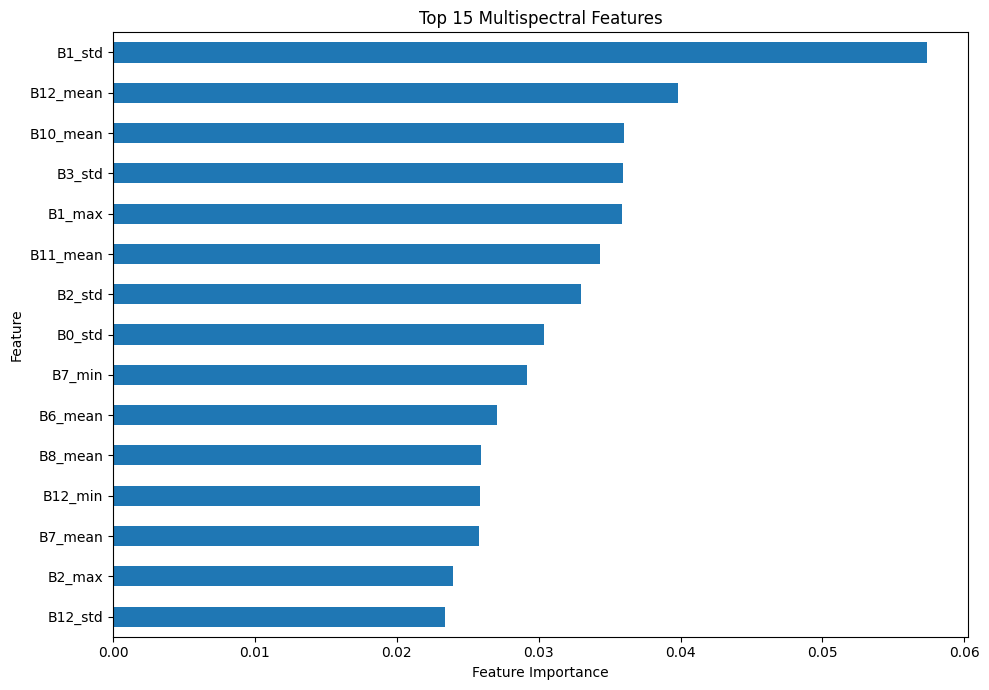

In [26]:
top_features = importances.head(15).sort_values()

plt.figure(figsize=(10, 7))

top_features.plot(kind='barh')

plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 15 Multispectral Features')

plt.tight_layout()

plt.savefig(
    'top_multispectral_features.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Stage 5: Exploring NDVI (Vegetation Index)

NDVI (Normalized Difference Vegetation Index) is a well-known formula
in remote sensing: it compares the Near-Infrared (NIR) and Red bands
to estimate how much vegetation is present in a pixel. Healthy plants
reflect a lot of NIR and absorb Red light, giving high NDVI values;
non-vegetated surfaces (roads, buildings, water) give low or negative
values.

    NDVI = (NIR - Red) / (NIR + Red)

Before adding this as a model feature, we explore it manually on a
few examples to build intuition for how it behaves.

In [16]:
sample = ms_dataset['train'][0]['image']
arr = np.array(sample).astype(float)

red = arr[:, :, 3]   # Red band
nir = arr[:, :, 7]   # Near-Infrared band

ndvi = (nir - red) / (nir + red)

print(ndvi.shape)   # (64, 64) -- one NDVI value per pixel
print(ndvi.mean())  # average NDVI across the whole image

print(label_names[ms_dataset['train'][0]['label']])  # check which class this image actually is

(64, 64)
0.18884719739670083
Annual Crop


**Observation:** Checking NDVI across several 'Annual Crop' images
showed a wide range of values (0.19 to 0.56). This makes sense: crop
fields look very different depending on growth stage (bare soil,
early sprouts, full growth, post-harvest stubble), so NDVI for a
single crop image isn't consistent — we need to look at the pattern
across *many* images, not just one, to draw real conclusions.

In [17]:
for i in [0, 1, 2, 3, 4]:
    example = ms_dataset['train'][i]
    arr = np.array(example['image']).astype(float)
    red = arr[:, :, 3]
    nir = arr[:, :, 7]
    ndvi = (nir - red) / (nir + red)
    print(label_names[example['label']], "= NDVI mean:", ndvi.mean())

Annual Crop = NDVI mean: 0.18884719739670083
Annual Crop = NDVI mean: 0.5613203012338317
Annual Crop = NDVI mean: 0.20183417793188024
Annual Crop = NDVI mean: 0.3481725844833261
Annual Crop = NDVI mean: 0.390693406983442


The dataset turned out to be sorted by class (all 'Annual Crop'
examples come first, then the next class, and so on), so the first
few hundred rows only contain one class. To find a 'Highway' example,
we have to search further into the dataset instead of just checking
the first few rows.

In [18]:
for i in range(len(ms_dataset['train'])):
    example = ms_dataset['train'][i]
    if label_names[example['label']] == 'Highway':
        arr = np.array(example['image']).astype(float)
        red = arr[:, :, 3]
        nir = arr[:, :, 7]
        ndvi = (nir - red) / (nir + red)
        print("Index:", i, "Highway = NDVI mean:", ndvi.mean())
        break  # stop after finding the first Highway example

Index: 5377 Highway = NDVI mean: 0.4754432651897824


Checking a handful of Highway examples (not just one) showed NDVI
values that were surprisingly high, similar to or even higher than
Annual Crop. The likely reason: each image covers a 640x640 meter
patch of ground (64 pixels x 10 meters/pixel), so a 'Highway' image
usually contains a lot of surrounding grass/fields alongside the road
itself, not just pure pavement. This means individual images are noisy
and unreliable to compare by eye — we need class-wide averages instead.

In [19]:
count = 0
for i in range(len(ms_dataset['train'])):
    example = ms_dataset['train'][i]
    if label_names[example['label']] == 'Highway':
        arr = np.array(example['image']).astype(float)
        red = arr[:, :, 3]
        nir = arr[:, :, 7]
        ndvi = (nir - red) / (nir + red)
        print("Index:", i, "NDVI mean:", ndvi.mean())
        count += 1
    if count == 5:
        break

Index: 5377 NDVI mean: 0.4754432651897824
Index: 5378 NDVI mean: 0.6650678198763071
Index: 5379 NDVI mean: 0.624373501684649
Index: 5380 NDVI mean: 0.5231503828036528
Index: 5381 NDVI mean: 0.3875047609123929


## Stage 5b: Compare NDVI Across Classes (Larger Sample)

Instead of eyeballing a handful of images, we compute the *average*
NDVI across 200 images per class. This smooths out the per-image noise
we saw above and shows whether there's a genuine, reliable difference
in vegetation content between classes.

In [ ]:
def get_ndvi_for_class(class_name, dataset_split, max_samples=200):
    ndvi_values = []
    count = 0
    for example in dataset_split:
        if label_names[example['label']] == class_name:
            arr = np.array(example['image']).astype(float)
            red = arr[:, :, 3]
            nir = arr[:, :, 7]
            ndvi = (nir - red) / (nir + red)
            ndvi_values.append(ndvi.mean())
            count += 1
        if count == max_samples:
            break
    return ndvi_values

highway_ndvi = get_ndvi_for_class('Highway', ms_dataset['train'])
crop_ndvi = get_ndvi_for_class('Annual Crop', ms_dataset['train'])

print("Highway - avg NDVI:", np.mean(highway_ndvi))
print("Annual Crop - avg NDVI:", np.mean(crop_ndvi))

# Reference check: classes with more "obvious" expected NDVI (Forest = very
# vegetated, SeaLake = water, no vegetation) to confirm NDVI behaves
# sensibly overall, even though Highway vs. Annual Crop turned out to be
# a genuinely hard case.
forest_ndvi = get_ndvi_for_class('Forest', ms_dataset['train'])
sealake_ndvi = get_ndvi_for_class('SeaLake', ms_dataset['train'])

print("Forest - avg NDVI:", np.mean(forest_ndvi))
print("SeaLake - avg NDVI:", np.mean(sealake_ndvi))

Highway - avg NDVI: 0.4408975106175499
Annual Crop - avg NDVI: 0.3583530596488677


## Stage 6: Add NDVI as a Model Feature

Even though NDVI alone doesn't cleanly separate Highway from crops,
it still carries useful information the model can combine with all
the other band statistics. We add NDVI's mean and std as 2 extra
features on top of the existing 52, giving 54 features per image.

Note: a small `eps` (tiny number) is added to the denominator to avoid
a divide-by-zero error/warning on pixels where NIR + Red happens to
equal 0.

In [ ]:
def extract_ms_features_v2(image):
    arr = np.array(image).astype(np.float64)

    features = []
    for band in range(arr.shape[2]):
        band_data = arr[:, :, band]
        features.append(band_data.mean())
        features.append(band_data.std())
        features.append(band_data.min())
        features.append(band_data.max())

    red = arr[:, :, 3]
    nir = arr[:, :, 7]

    eps = 1e-8  # prevents 0/0 division errors
    ndvi = (nir - red) / (nir + red + eps)
    features.append(ndvi.mean())
    features.append(ndvi.std())

    return features

def build_feature_matrix_ms_v2(dataset_split):
    X = []
    y = []
    for example in dataset_split:
        X.append(extract_ms_features_v2(example['image']))
        y.append(example['label'])
    return np.array(X), np.array(y)

X_train_v2, y_train_v2 = build_feature_matrix_ms_v2(ms_dataset['train'])
X_val_v2, y_val_v2 = build_feature_matrix_ms_v2(ms_dataset['validation'])

rf_v2 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_v2.fit(X_train_v2, y_train_v2)

y_val_pred_v2 = rf_v2.predict(X_val_v2)
print("Accuracy with NDVI:", accuracy_score(y_val_v2, y_val_pred_v2))
print(classification_report(y_val_v2, y_val_pred_v2, target_names=label_names))

## Stage 6b: Final Test Set Evaluation

Validation accuracy is used to guide decisions during development, but
the test set is data we've never touched until now — it gives the
final, unbiased number that reflects real-world performance.

In [ ]:
X_test_v2, y_test_v2 = build_feature_matrix_ms_v2(ms_dataset['test'])

y_test_pred_v2 = rf_v2.predict(X_test_v2)
print("Test Accuracy:", accuracy_score(y_test_v2, y_test_pred_v2))
print(classification_report(y_test_v2, y_test_pred_v2, target_names=label_names))

## Stage 6C: Multispectral + NDVI confusion matrix

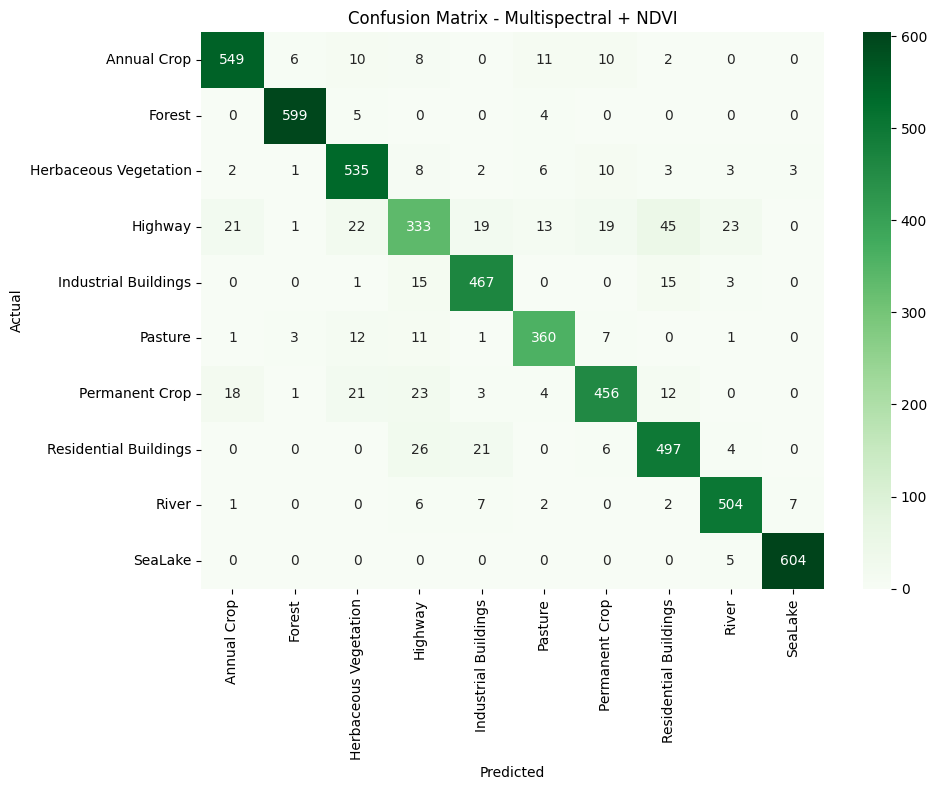

In [25]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_final = confusion_matrix(y_test_v2, y_test_pred_v2)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_final,
    annot=True,
    fmt='d',
    xticklabels=label_names,
    yticklabels=label_names,
    cmap='Greens'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Multispectral + NDVI')
plt.tight_layout()

plt.savefig(
    'multispectral_ndvi_confusion_matrix.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Stage 6D: Save the Final Model

Same as before: save the trained model and features to disk (and
download them), so this final stage of work is preserved.

In [24]:
import os
print(os.path.exists('models'))
print(os.listdir('.') if not os.path.exists('models') else os.listdir('models'))

import pickle

with open('models/rf_ms_ndvi.pkl', 'wb') as f:
    pickle.dump(rf_v2, f)

print("Model saved successfully")

np.savez('models/ms_ndvi_features.npz',
         X_train=X_train_v2, y_train=y_train_v2,
         X_val=X_val_v2, y_val=y_val_v2,
         X_test=X_test_v2, y_test=y_test_v2)

print("Features saved successfully")

# verify both files exist before downloading
print(os.listdir('models'))

from google.colab import files
files.download('models/rf_ms_ndvi.pkl')
files.download('models/ms_ndvi_features.npz')

True
['rf_ms_ndvi.pkl', 'rgb_features.npz', 'ms_ndvi_features.npz', 'rf_baseline_rgb.pkl']
Model saved successfully
Features saved successfully
['rf_ms_ndvi.pkl', 'rgb_features.npz', 'ms_ndvi_features.npz', 'rf_baseline_rgb.pkl']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Stage 7 Results: Multispectral + NDVI (Random Forest)

- **Model:** Random Forest (100 trees), trained on 13 spectral bands
  (mean/std/min/max per band) + NDVI (mean/std)
- **Validation Accuracy:** 90.6%
- **Test Accuracy:** 90.8%
- **Improvement over RGB baseline:** +12.3 percentage points
- **Weakest class:** Highway (F1 0.71-0.72) — still confused mainly
  with Residential/Industrial Buildings rather than River, likely
  because roads and buildings share similar paved-surface spectral signatures
- **Key finding:** Adding SWIR/NIR bands and NDVI meaningfully
  improved separation of vegetation vs. non-vegetation and water vs.
  land, but paved surfaces (Highway, Residential, Industrial) remain
  hard to distinguish from each other with simple statistical features.


